# Regression Baseline: Increasing Model Complexity

This notebook trains regression models on the stratified county split data (CASTHMA and COPD targets), **increasing in complexity** following the data science lecture sequence:

1. **Simple linear regression** (one feature) — *04_linear_regression/01_simple_linear_regression*
2. **Multiple linear regression** (numeric features only) — *04_linear_regression/02_multiple_linear_regression*
3. **Categorical variables and preprocessing** (pipeline: impute, scale, one-hot) — *04_linear_regression/03_categorical_variables_and_interaction*
4. **Regularization (Ridge, Lasso, ElasticNet)** — *03_complexity_control/02_regularization*
5. **Hyperparameter tuning** (GridSearchCV with grouped CV) — *03_complexity_control/04_hyperparameter_tuning*
6. **XGBoost** — *11_ensemble_ii/04_xgboost*

Enhancements: **both targets** (CASTHMA & COPD), **CV metrics** and **bootstrap CIs** for test metrics, **diagnostic plots** for all linear/ensemble models, **unified top-features** table, **SHAP** for XGBoost, and an **interpretation** section. Model 2/3 use **Ridge** (not OLS) for stability.

### Notebook map (what each block does)

| Block | Purpose |
|-------|--------|
| **Setup** | Imports, paths, `TARGETS`, CV constants. |
| **Data** | Five **exposure sets** (see below), including **Full_pesticides_raw** (all `pesticide_*_kg`). |
| **Models × exposures** | Seven model families × five exposure sets (incl. **Full_pesticides_raw**) for CASTHMA & COPD. |
| **Plots / SHAP** | **CASTHMA** + **Aggs_engineered** (change `PLOT_EXPOSURE_KEY` in the models cell to switch). |
| **Export** | Bootstrap RMSE CIs + CSVs per target (`model_summary_exposure_sets.csv`, predictions for Aggs_engineered). |


## Setup and paths

In [23]:
# --- Setup (run first) ---
# 1) Import libraries and sklearn pieces used everywhere below.
# 2) REPO_ROOT / DATA_DIR / RESULTS_DIR so paths work from repo or modeling/.
# 3) TARGET_PATHS, DEFAULT_DROP_COLUMNS, ALPHA_GRID, CV_FOLDS, TARGETS.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style("whitegrid")

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "modeling" else Path.cwd()
DATA_DIR = REPO_ROOT / "data"
RESULTS_DIR = REPO_ROOT / "modeling" / "results"

TARGET_PATHS = {
    "CASTHMA": {"train": DATA_DIR / "train_CASTHMA.csv", "test": DATA_DIR / "test_CASTHMA.csv"},
    "COPD": {"train": DATA_DIR / "train_COPD.csv", "test": DATA_DIR / "test_COPD.csv"},
}

DEFAULT_DROP_COLUMNS = {
    "index", "FIPS", "NAME", "state_fips", "CASTHMA", "COPD",
    "CSMOKING", "OBESITY", "DIABETES", "cat3_CASTHMA", "cat3_COPD",
}

ALPHA_GRID = np.logspace(-3, 3, 13)
RANDOM_STATE = 42
CV_FOLDS = 5
N_BOOT = 100   # bootstrap samples for test-metric CIs

# Run for both targets
TARGETS = ["CASTHMA", "COPD"]

## Data splits (train / test)

Following *02_model_evaluation/01_data_splits*: we use a **training set** to fit and compare models, and a **testing set** only for final evaluation. The data are already split by county (stratified) so we load pre-made train/test files.

## Exposure sets (used throughout)

Same **demographic / health / land-use / YEAR** block (`BASE_COLS`) for all runs. Pesticide signal varies:

| Set | Pesticide predictors |
|-----|----------------------|
| **Aggs_raw** | County kg rollups (respiratory, total, class totals). |
| **Aggs_engineered** | Those kg + log1p(per-capita) & log1p(per-cropland-acre) per rollup. |
| **Components_raw** | OP, carbamate, pyrethroid kg only. |
| **Components_engineered** | Six log-intensity features for those classes. |
| **Full_pesticides_raw** | Every **pesticide_*_kg** column (~400+ compounds + class/total rollups) + BASE_COLS; raw kg. |


In [24]:
# --- Data splits ---
# Five exposure designs (+ Full_pesticides_raw: every pesticide_*_kg) + shared BASE_COLS.

def choose_feature_columns(train_df: pd.DataFrame, target: str) -> list:
    drop = set(DEFAULT_DROP_COLUMNS)
    lc = {c: str(c).lower() for c in train_df.columns}
    for c, name in lc.items():
        if name.startswith("ipm_") or name.startswith("chemical_reliance"):
            drop.add(c)
    drop.update(
        c for c in train_df.columns
        if c in {"mean_text_quality", "mean_geo_confidence", "weighted_doc_age", "total_ag_value"}
    )
    return [c for c in train_df.columns if c not in drop]


# Embedded into model_selection data cell — four exposure designs + engineer

def engineer_signal_isolation_features(df: pd.DataFrame) -> pd.DataFrame:
    """Per-capita / per-cropland-acre loads, log1p intensities, rural_binary."""

    def safe_divide(num, denom):
        denom_arr = denom.to_numpy() if hasattr(denom, "to_numpy") else denom
        num_arr = num.to_numpy() if hasattr(num, "to_numpy") else num
        out = np.where(denom_arr == 0, np.nan, num_arr / denom_arr)
        return pd.Series(out, index=getattr(num, "index", None)) if hasattr(num, "index") else out

    df = df.copy()
    df["resp_per_capita"] = safe_divide(df["pesticide_respiratory_kg"], df["population"])
    df["resp_per_cropland_acre"] = safe_divide(df["pesticide_respiratory_kg"], df["cropland_acres"])

    for kg_col in AGGREGATE_KG_PROXIES:
        if kg_col not in df.columns or kg_col == "pesticide_respiratory_kg":
            continue
        slug = kg_col.replace("pesticide_", "").replace("_kg", "")
        pc, pa = f"{slug}_per_capita", f"{slug}_per_cropland_acre"
        df[pc] = safe_divide(df[kg_col], df["population"])
        df[pa] = safe_divide(df[kg_col], df["cropland_acres"])
        df[f"log_{pc}"] = np.log1p(df[pc])
        df[f"log_{pa}"] = np.log1p(df[pa])

    df["op_per_capita"] = safe_divide(df["pesticide_organophosphate_kg"], df["population"])
    df["op_per_cropland_acre"] = safe_divide(df["pesticide_organophosphate_kg"], df["cropland_acres"])
    df["carbamate_per_capita"] = safe_divide(df["pesticide_carbamate_kg"], df["population"])
    df["carbamate_per_cropland_acre"] = safe_divide(df["pesticide_carbamate_kg"], df["cropland_acres"])
    df["pyrethroid_per_capita"] = safe_divide(df["pesticide_pyrethroid_kg"], df["population"])
    df["pyrethroid_per_cropland_acre"] = safe_divide(df["pesticide_pyrethroid_kg"], df["cropland_acres"])

    for col in [
        "resp_per_capita", "resp_per_cropland_acre", "op_per_capita", "op_per_cropland_acre",
        "carbamate_per_capita", "carbamate_per_cropland_acre",
        "pyrethroid_per_capita", "pyrethroid_per_cropland_acre",
    ]:
        df[f"log_{col}"] = np.log1p(df[col])

    df["rural_binary"] = (df["nchs_urban_rural"] >= 5).astype(int)
    return df


AGGREGATE_KG_PROXIES = [
    "pesticide_respiratory_kg", "pesticide_total_kg", "pesticide_chlorophenoxy_kg",
    "pesticide_triazine_kg", "pesticide_anilide_kg", "pesticide_organochlorine_kg", "pesticide_other_kg",
]


def _aggregate_log_intensity_feature_names():
    names = ["log_resp_per_capita", "log_resp_per_cropland_acre"]
    for kg_col in AGGREGATE_KG_PROXIES:
        if kg_col == "pesticide_respiratory_kg":
            continue
        slug = kg_col.replace("pesticide_", "").replace("_kg", "")
        names.extend([f"log_{slug}_per_capita", f"log_{slug}_per_cropland_acre"])
    return names


AGGREGATE_LOG_INTENSITY = _aggregate_log_intensity_feature_names()
PEST_AGGREGATE_ORDER = list(dict.fromkeys(AGGREGATE_KG_PROXIES + AGGREGATE_LOG_INTENSITY))
PEST_COMPONENTS = [
    "log_op_per_capita", "log_op_per_cropland_acre",
    "log_carbamate_per_capita", "log_carbamate_per_cropland_acre",
    "log_pyrethroid_per_capita", "log_pyrethroid_per_cropland_acre",
]
COMPONENT_KG_RAW = [
    "pesticide_organophosphate_kg", "pesticide_carbamate_kg", "pesticide_pyrethroid_kg",
]

DEMO_COLS = [
    "population", "median_age", "median_income", "pct_white", "pct_black",
    "pct_asian", "pct_hispanic", "rural_binary",
]
HEALTH_CONFOUNDER_COLS = ["CSMOKING", "OBESITY", "DIABETES"]
CROPLAND_COLS = ["cropland_diversity", "county_crop_concentration", "pct_cropland"]
OTHER_COLS = ["YEAR"]
BASE_COLS = DEMO_COLS + HEALTH_CONFOUNDER_COLS + CROPLAND_COLS + OTHER_COLS

EXPOSURE_SETS = {
    "Aggs_raw": list(dict.fromkeys(AGGREGATE_KG_PROXIES + BASE_COLS)),
    "Aggs_engineered": list(dict.fromkeys(AGGREGATE_KG_PROXIES + AGGREGATE_LOG_INTENSITY + BASE_COLS)),
    "Components_raw": list(dict.fromkeys(COMPONENT_KG_RAW + BASE_COLS)),
    "Components_engineered": list(dict.fromkeys(PEST_COMPONENTS + BASE_COLS)),
}
# Full_pesticides_raw is built per-split in the data cell (all pesticide_*_kg + BASE_COLS).
FULL_PESTICIDES_RAW_KEY = "Full_pesticides_raw"
EXPOSURE_SET_KEYS = list(EXPOSURE_SETS.keys()) + [FULL_PESTICIDES_RAW_KEY]


data = {}
for TARGET in TARGETS:
    train_df = pd.read_csv(TARGET_PATHS[TARGET]["train"])
    test_df = pd.read_csv(TARGET_PATHS[TARGET]["test"])
    feature_columns = choose_feature_columns(train_df, TARGET)
    etr = engineer_signal_isolation_features(train_df.copy())
    ete = engineer_signal_isolation_features(test_df.copy())
    X_by = {}
    for k, cols in EXPOSURE_SETS.items():
        use = [c for c in cols if c in etr.columns]
        X_by[k] = (etr[use].copy(), ete[use].copy())
    pest_kg_cols = sorted(c for c in train_df.columns if str(c).startswith("pesticide_") and str(c).endswith("_kg"))
    full_raw = [c for c in list(dict.fromkeys(pest_kg_cols + BASE_COLS)) if c in etr.columns and c in ete.columns]
    X_by[FULL_PESTICIDES_RAW_KEY] = (etr[full_raw].copy(), ete[full_raw].copy())
    data[TARGET] = {
        "train_df": train_df,
        "test_df": test_df,
        "train_eng": etr,
        "test_eng": ete,
        "X_by_exposure": X_by,
        "X_train": train_df[feature_columns].copy(),
        "y_train": train_df[TARGET].copy(),
        "y_test": test_df[TARGET].copy(),
        "groups": train_df["FIPS"].copy(),
        "feature_columns": feature_columns,
    }
    print(f"{TARGET}: train {len(train_df)}, test {len(test_df)}, full pipeline cols {len(feature_columns)} | exposure sets: {list(X_by.keys())}")

TARGET = TARGETS[0]
PLOT_EXPOSURE_KEY = "Aggs_engineered"
y_train = data[TARGET]["y_train"]
y_test = data[TARGET]["y_test"]
groups = data[TARGET]["groups"]
X_train, X_test = data[TARGET]["X_by_exposure"][PLOT_EXPOSURE_KEY]
feature_columns = data[TARGET]["feature_columns"]
data[TARGET]["X_train"].head()


CASTHMA: train 4871, test 1217, full pipeline cols 468 | exposure sets: ['Aggs_raw', 'Aggs_engineered', 'Components_raw', 'Components_engineered', 'Full_pesticides_raw']
COPD: train 4871, test 1217, full pipeline cols 468 | exposure sets: ['Aggs_raw', 'Aggs_engineered', 'Components_raw', 'Components_engineered', 'Full_pesticides_raw']


,YEAR,pesticide_total_kg,pesticide_anilide_kg,pesticide_carbamate_kg,pesticide_chlorophenoxy_kg,pesticide_organochlorine_kg,pesticide_organophosphate_kg,pesticide_other_kg,pesticide_pyrethroid_kg,pesticide_triazine_kg,...,soybean_acres,cotton_acres,wheat_acres,hay_acres,fruit_veg_acres,rice_acres,sorghum_acres,cropland_diversity,county_crop_concentration,specialty_crop_share
0,2018,34773.85,3690.60,397.30,6995.35,0.0,2033.75,20854.80,119.65,682.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38.0,0.135210,0.0
1,2019,21120.00,2582.55,9.70,5230.55,0.0,763.95,11639.25,16.80,877.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38.0,0.135210,0.0
2,2018,277331.10,61192.90,1327.20,10561.50,0.0,4287.00,185663.25,1982.75,12316.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,44.0,0.218801,0.0
3,2019,125643.65,30532.30,24.45,4197.00,0.0,7219.45,75275.55,127.30,8267.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,44.0,0.218801,0.0
4,2018,63256.35,3484.60,306.80,11760.30,0.0,1455.95,42686.50,626.70,2935.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41.0,0.211528,0.0


---
## Models 1–7 × exposure sets

For each target (CASTHMA, COPD) and each exposure set (**Aggs_raw**, **Aggs_engineered**, **Components_raw**, **Components_engineered**, **Full_pesticides_raw**), we fit: Simple LR (1 feat), multiple Ridge (numeric), Ridge (full preprocess), tuned Ridge/Lasso/ElasticNet, XGBoost. **Diagnostic plots / SHAP / coef tables** below use **CASTHMA** + **Aggs_engineered** by default (`PLOT_EXPOSURE_KEY`).


In [25]:
def make_strata(y: pd.Series, n_bins: int = 5) -> pd.Series:
    n_unique = y.nunique(dropna=True)
    bins = max(2, min(n_bins, n_unique))
    return pd.qcut(y, q=bins, labels=False, duplicates="drop")


def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = [c for c in X.columns if c not in numeric_features]
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
    )


SI_TOP_N = 8
SI_XGB_PARAM_GRID = {
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.05, 0.1],
    "model__n_estimators": [100, 200],
}
SI_MODEL_ORDER = [
    "Simple LR (1 feat)", "Multiple LR (Ridge, numeric)", "Multiple LR (Ridge, full preprocess)",
    "Ridge (tuned)", "Lasso (tuned)", "ElasticNet (tuned)", "XGBoost (tuned)",
]


def top_coefficients_from_linear_search(search, top_n=SI_TOP_N):
    names = search.best_estimator_.named_steps["preprocess"].get_feature_names_out()
    coef = search.best_estimator_.named_steps["model"].coef_
    df = pd.DataFrame({"feature": names, "coefficient": coef, "abs_coef": np.abs(coef)})
    return df.sort_values("abs_coef", ascending=False).head(top_n)


def top_importances_from_xgb_search(search, top_n=SI_TOP_N):
    fnames = search.best_estimator_.named_steps["preprocess"].get_feature_names_out()
    im = search.best_estimator_.named_steps["model"].feature_importances_
    return pd.DataFrame({"feature": fnames, "importance": im}).sort_values("importance", ascending=False).head(top_n)


def run_exposure_models_all(target, exposure_name, X_tr, X_te, y_tr, y_te, folds):
    feature_cols = list(X_tr.columns)
    if exposure_name == "Aggs_raw":
        pool = [c for c in AGGREGATE_KG_PROXIES if c in feature_cols]
    elif exposure_name == "Full_pesticides_raw":
        pool = sorted(c for c in feature_cols if str(c).startswith("pesticide_") and str(c).endswith("_kg"))
    elif exposure_name == "Aggs_engineered":
        pool = [c for c in PEST_AGGREGATE_ORDER if c in feature_cols]
    elif exposure_name == "Components_raw":
        pool = [c for c in COMPONENT_KG_RAW if c in feature_cols]
    else:
        pool = [c for c in PEST_COMPONENTS if c in feature_cols]
    if exposure_name == "Full_pesticides_raw" and pool:
        single_pest = "pesticide_total_kg" if "pesticide_total_kg" in feature_cols else pool[0]
    else:
        single_pest = pool[0] if pool else feature_cols[0]

    imp_single = SimpleImputer(strategy="median")
    x_tr_s = imp_single.fit_transform(X_tr[[single_pest]])
    x_te_s = imp_single.transform(X_te[[single_pest]])
    m_simple = LinearRegression().fit(x_tr_s, y_tr)
    pred_simple = m_simple.predict(x_te_s)
    simple_top = pd.DataFrame({"feature": [single_pest], "coefficient": [float(m_simple.coef_[0])], "abs_coef": [float(np.abs(m_simple.coef_[0]))]})

    numeric_cols = X_tr.select_dtypes(include=["number", "bool"]).columns.tolist()
    pipe_num = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ])
    pipe_num.fit(X_tr[numeric_cols], y_tr)
    pred_multi_numeric = pipe_num.predict(X_te[numeric_cols])
    ridge_numeric_top = (
        pd.DataFrame({"feature": numeric_cols, "coefficient": pipe_num.named_steps["model"].coef_, "abs_coef": np.abs(pipe_num.named_steps["model"].coef_)})
        .sort_values("abs_coef", ascending=False).head(SI_TOP_N)
    )

    preproc_full = build_preprocessor(X_tr)
    X_tr_f = preproc_full.fit_transform(X_tr)
    X_te_f = preproc_full.transform(X_te)
    m_full = Ridge(alpha=1.0).fit(X_tr_f, y_tr)
    pred_multi_full = m_full.predict(X_te_f)
    ridge_full_top = (
        pd.DataFrame({"feature": preproc_full.get_feature_names_out(), "coefficient": m_full.coef_, "abs_coef": np.abs(m_full.coef_)})
        .sort_values("abs_coef", ascending=False).head(SI_TOP_N)
    )

    preproc = build_preprocessor(X_tr)
    ridge_search = GridSearchCV(
        Pipeline([("preprocess", preproc), ("model", Ridge())]),
        param_grid={"model__alpha": ALPHA_GRID}, cv=folds, scoring="neg_root_mean_squared_error", refit=True, n_jobs=1,
    ).fit(X_tr, y_tr)
    pred_ridge = ridge_search.predict(X_te)

    lasso_search = GridSearchCV(
        Pipeline([("preprocess", preproc), ("model", Lasso(max_iter=20000, random_state=RANDOM_STATE))]),
        param_grid={"model__alpha": ALPHA_GRID}, cv=folds, scoring="neg_root_mean_squared_error", refit=True, n_jobs=1,
    ).fit(X_tr, y_tr)
    pred_lasso = lasso_search.predict(X_te)

    elastic_search = GridSearchCV(
        Pipeline([("preprocess", preproc), ("model", ElasticNet(max_iter=20000, random_state=RANDOM_STATE))]),
        param_grid={"model__alpha": ALPHA_GRID, "model__l1_ratio": [0.25, 0.5, 0.75]},
        cv=folds, scoring="neg_root_mean_squared_error", refit=True, n_jobs=1,
    ).fit(X_tr, y_tr)
    pred_elastic = elastic_search.predict(X_te)

    xgb_search = GridSearchCV(
        Pipeline([("preprocess", preproc), ("model", XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1))]),
        param_grid=SI_XGB_PARAM_GRID, cv=folds, scoring="neg_root_mean_squared_error", refit=True, n_jobs=1,
    ).fit(X_tr, y_tr)
    pred_xgb = xgb_search.predict(X_te)

    preds = {
        "Simple LR (1 feat)": pred_simple,
        "Multiple LR (Ridge, numeric)": pred_multi_numeric,
        "Multiple LR (Ridge, full preprocess)": pred_multi_full,
        "Ridge (tuned)": pred_ridge,
        "Lasso (tuned)": pred_lasso,
        "ElasticNet (tuned)": pred_elastic,
        "XGBoost (tuned)": pred_xgb,
    }
    top_features = {
        "Simple LR (1 feat)": simple_top,
        "Multiple LR (Ridge, numeric)": ridge_numeric_top,
        "Multiple LR (Ridge, full preprocess)": ridge_full_top,
        "Ridge (tuned)": top_coefficients_from_linear_search(ridge_search),
        "Lasso (tuned)": top_coefficients_from_linear_search(lasso_search),
        "ElasticNet (tuned)": top_coefficients_from_linear_search(elastic_search),
        "XGBoost (tuned)": top_importances_from_xgb_search(xgb_search),
    }
    rows = []
    for model_name in SI_MODEL_ORDER:
        pred = preds[model_name]
        row = {
            "target": target, "exposure_set": exposure_name, "model": model_name,
            "rmse": float(np.sqrt(mean_squared_error(y_te, pred))),
            "mae": float(mean_absolute_error(y_te, pred)),
            "r2": float(r2_score(y_te, pred)),
            "best_alpha": np.nan, "best_l1_ratio": np.nan, "best_params": np.nan,
        }
        if model_name == "Ridge (tuned)":
            row["best_alpha"] = ridge_search.best_params_["model__alpha"]
        elif model_name == "Lasso (tuned)":
            row["best_alpha"] = lasso_search.best_params_["model__alpha"]
        elif model_name == "ElasticNet (tuned)":
            row["best_alpha"] = elastic_search.best_params_["model__alpha"]
            row["best_l1_ratio"] = elastic_search.best_params_["model__l1_ratio"]
        elif model_name == "XGBoost (tuned)":
            row["best_params"] = repr(xgb_search.best_params_)
        rows.append(row)

    bundle = {
        "ridge_search": ridge_search, "lasso_search": lasso_search, "elastic_search": elastic_search, "xgb_search": xgb_search,
        "pred_ridge": pred_ridge, "pred_lasso": pred_lasso, "pred_elastic": pred_elastic, "pred_xgb": pred_xgb,
        "preds": preds,
    }
    return pd.DataFrame(rows), top_features, bundle


fitted_store = {}
summaries = []
for target in TARGETS:
    print(f"\n=== {target} ===")
    d = data[target]
    etr, ete = d["train_eng"], d["test_eng"]
    y_tr, y_te = d["y_train"], d["y_test"]
    strata = make_strata(y_tr)
    folds = list(
        StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE).split(d["X_train"], strata, d["groups"])
    )
    for ek in EXPOSURE_SET_KEYS:
        X_tr, X_te = d["X_by_exposure"][ek]
        print(f"  {ek}: {X_tr.shape[1]} cols")
        summary_df, _top, bundle = run_exposure_models_all(target, ek, X_tr, X_te, y_tr, y_te, folds)
        fitted_store[(target, ek)] = bundle
        summaries.append(summary_df)

exposure_summary_all = pd.concat(summaries, ignore_index=True)
print("\n=== All targets × exposure sets × models (sorted by RMSE) ===")
from IPython.display import HTML

df_sorted = exposure_summary_all.sort_values(["target", "exposure_set", "rmse"])
display(HTML(f'<div style="max-height:500px; overflow:auto;">{df_sorted.to_html()}</div>'))

TARGET = TARGETS[0]
PLOT_EXPOSURE_KEY = "Aggs_engineered"
b = fitted_store[(TARGET, PLOT_EXPOSURE_KEY)]
ridge_search, lasso_search, elastic_search, xgb_search = b["ridge_search"], b["lasso_search"], b["elastic_search"], b["xgb_search"]
pred_ridge, pred_lasso, pred_elastic, pred_xgb = b["pred_ridge"], b["pred_lasso"], b["pred_elastic"], b["pred_xgb"]
y_test = data[TARGET]["y_test"]
y_train = data[TARGET]["y_train"]
X_train, X_test = data[TARGET]["X_by_exposure"][PLOT_EXPOSURE_KEY]
print(f"Plots use TARGET={TARGET}, exposure={PLOT_EXPOSURE_KEY}")



=== CASTHMA ===
  Aggs_raw: 22 cols
  Aggs_engineered: 36 cols
  Components_raw: 18 cols
  Components_engineered: 21 cols
  Full_pesticides_raw: 460 cols

=== COPD ===
  Aggs_raw: 22 cols
  Aggs_engineered: 36 cols
  Components_raw: 18 cols
  Components_engineered: 21 cols
  Full_pesticides_raw: 460 cols

=== All targets × exposure sets × models (sorted by RMSE) ===


,target,exposure_set,model,rmse,mae,r2,best_alpha,best_l1_ratio,best_params
13,CASTHMA,Aggs_engineered,XGBoost (tuned),0.452622,0.346478,0.792281,NaN,NaN,"{'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 200}"
11,CASTHMA,Aggs_engineered,Lasso (tuned),0.601335,0.472490,0.633361,0.001000,NaN,NaN
12,CASTHMA,Aggs_engineered,ElasticNet (tuned),0.602008,0.473536,0.632540,0.001000,0.25,NaN
10,CASTHMA,Aggs_engineered,Ridge (tuned),0.602548,0.474111,0.631881,3.162278,NaN,NaN
8,CASTHMA,Aggs_engineered,"Multiple LR (Ridge, numeric)",0.602875,0.474430,0.631481,NaN,NaN,NaN
9,CASTHMA,Aggs_engineered,"Multiple LR (Ridge, full preprocess)",0.602875,0.474430,0.631481,NaN,NaN,NaN
7,CASTHMA,Aggs_engineered,Simple LR (1 feat),0.992799,0.785496,0.000625,NaN,NaN,NaN
6,CASTHMA,Aggs_raw,XGBoost (tuned),0.457434,0.348136,0.787840,NaN,NaN,"{'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 200}"
3,CASTHMA,Aggs_raw,Ridge (tuned),0.624568,0.493786,0.604483,3.162278,NaN,NaN
1,CASTHMA,Aggs_raw,"Multiple LR (Ridge, numeric)",0.624583,0.493789,0.604465,NaN,NaN,NaN


Plots use TARGET=CASTHMA, exposure=Aggs_engineered


---
## Regression diagnostic plots

As in *02_model_evaluation/03_regression_plots*: **actual vs predicted** and **residuals** to assess fit and homoscedasticity.

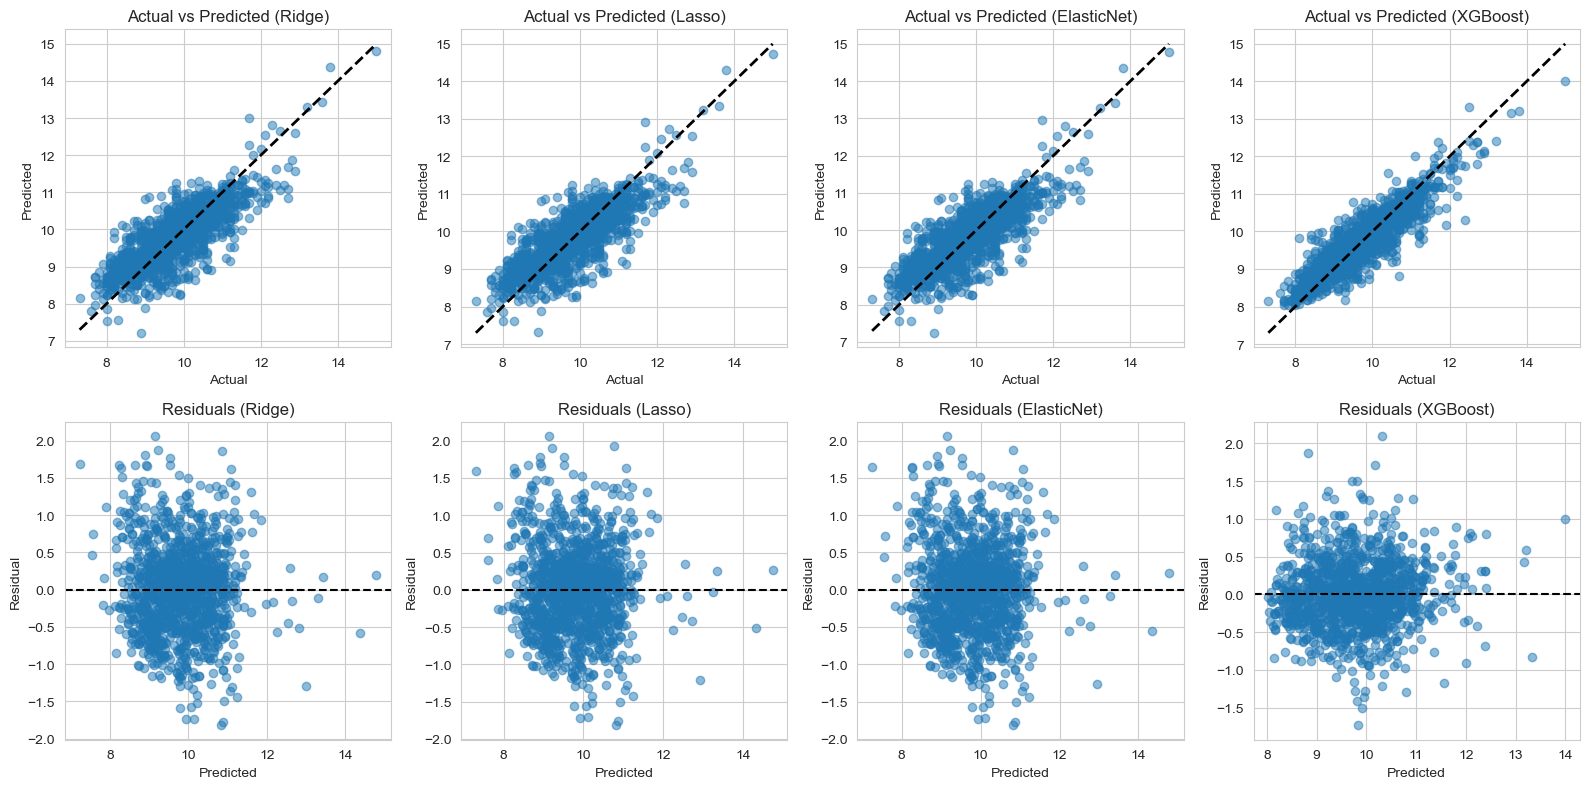

In [50]:
# Diagnostic plots for Ridge, Lasso, ElasticNet, XGBoost
plot_models = [("Ridge", pred_ridge), ("Lasso", pred_lasso), ("ElasticNet", pred_elastic), ("XGBoost", pred_xgb)]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for j, (name, y_pred_plot) in enumerate(plot_models):
    resid = y_test - y_pred_plot
    axes[0, j].scatter(y_test, y_pred_plot, alpha=0.5)
    axes[0, j].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
    axes[0, j].set_xlabel("Actual")
    axes[0, j].set_ylabel("Predicted")
    axes[0, j].set_title(f"Actual vs Predicted ({name})")
    axes[1, j].scatter(y_pred_plot, resid, alpha=0.5)
    axes[1, j].axhline(0, color="k", ls="--")
    axes[1, j].set_xlabel("Predicted")
    axes[1, j].set_ylabel("Residual")
    axes[1, j].set_title(f"Residuals ({name})")
plt.tight_layout()
plt.show()


---
## Top coefficients / feature importances (Ridge / Lasso / XGBoost)

Inspect which features (after preprocessing) have the largest absolute coefficients (Ridge, Lasso) or the largest feature importance (XGBoost). Lasso often zeros out some; Ridge shrinks but rarely to zero.

In [51]:
def top_coefficients(search, top_n=15):
    names = search.best_estimator_.named_steps["preprocess"].get_feature_names_out()
    coef = search.best_estimator_.named_steps["model"].coef_
    df = pd.DataFrame({"feature": names, "coefficient": coef, "abs_coef": np.abs(coef)})
    return df.sort_values("abs_coef", ascending=False).head(top_n)

print("Ridge — top 15 by |coefficient|")
display(top_coefficients(ridge_search))
print("Lasso — top 15 by |coefficient|")
display(top_coefficients(lasso_search))
print("ElasticNet — top 15 by |coefficient|")
display(top_coefficients(elastic_search))
print("XGBoost — top 15 by feature importance")
fnames = xgb_search.best_estimator_.named_steps["preprocess"].get_feature_names_out()
imp = xgb_search.best_estimator_.named_steps["model"].feature_importances_
display(pd.DataFrame({"feature": fnames, "importance": imp}).sort_values("importance", ascending=False).head(15))

Ridge — top 15 by |coefficient|


,feature,coefficient,abs_coef
27,num__pct_hispanic,-0.615982,0.615982
9,num__log_total_per_capita,-0.519959,0.519959
24,num__pct_white,-0.453844,0.453844
10,num__log_total_per_cropland_acre,-0.377775,0.377775
29,num__CSMOKING,0.364141,0.364141
25,num__pct_black,-0.325495,0.325495
16,num__log_anilide_per_cropland_acre,0.293332,0.293332
15,num__log_anilide_per_capita,-0.286912,0.286912
19,num__log_other_per_capita,0.282511,0.282511
23,num__median_income,-0.221694,0.221694


Lasso — top 15 by |coefficient|


,feature,coefficient,abs_coef
27,num__pct_hispanic,-0.605247,0.605247
9,num__log_total_per_capita,-0.464668,0.464668
24,num__pct_white,-0.443213,0.443213
29,num__CSMOKING,0.364562,0.364562
25,num__pct_black,-0.310888,0.310888
15,num__log_anilide_per_capita,-0.254040,0.254040
23,num__median_income,-0.223651,0.223651
19,num__log_other_per_capita,0.218314,0.218314
13,num__log_triazine_per_capita,0.175360,0.175360
32,num__cropland_diversity,0.173210,0.173210


ElasticNet — top 15 by |coefficient|


,feature,coefficient,abs_coef
27,num__pct_hispanic,-0.611380,0.611380
9,num__log_total_per_capita,-0.504534,0.504534
24,num__pct_white,-0.449057,0.449057
29,num__CSMOKING,0.364420,0.364420
25,num__pct_black,-0.319633,0.319633
15,num__log_anilide_per_capita,-0.277471,0.277471
19,num__log_other_per_capita,0.264489,0.264489
10,num__log_total_per_cropland_acre,-0.255087,0.255087
16,num__log_anilide_per_cropland_acre,0.234869,0.234869
23,num__median_income,-0.222358,0.222358


XGBoost — top 15 by feature importance


,feature,importance
29,num__CSMOKING,0.392178
15,num__log_anilide_per_capita,0.073304
31,num__DIABETES,0.061419
32,num__cropland_diversity,0.042716
23,num__median_income,0.040572
27,num__pct_hispanic,0.039035
11,num__log_chlorophenoxy_per_capita,0.031364
24,num__pct_white,0.027080
35,num__YEAR,0.025767
25,num__pct_black,0.024645


---
## Unified top features (Ridge / Lasso / ElasticNet / XGBoost)

Top 10 features side by side for easy comparison across models.

In [52]:
top_n = 50
ridge_top = top_coefficients(ridge_search, top_n=top_n)[["feature", "abs_coef"]].rename(columns={"abs_coef": "Ridge"})
lasso_top = top_coefficients(lasso_search, top_n=top_n)[["feature", "abs_coef"]].rename(columns={"abs_coef": "Lasso"})
elastic_top = top_coefficients(elastic_search, top_n=top_n)[["feature", "abs_coef"]].rename(columns={"abs_coef": "ElasticNet"})
xgb_imp = pd.DataFrame({"feature": xgb_search.best_estimator_.named_steps["preprocess"].get_feature_names_out(), "XGBoost": xgb_search.best_estimator_.named_steps["model"].feature_importances_}).sort_values("XGBoost", ascending=False).head(top_n)
# Align by feature (inner join on feature name)
unified = ridge_top.merge(lasso_top, on="feature", how="outer").merge(elastic_top, on="feature", how="outer").merge(xgb_imp[["feature", "XGBoost"]], on="feature", how="outer").fillna(0)
display(unified.head(top_n))

,feature,Ridge,Lasso,ElasticNet,XGBoost
0,num__CSMOKING,0.364141,3.645619e-01,0.364420,0.392178
1,num__DIABETES,0.165693,1.597324e-01,0.163934,0.061419
2,num__OBESITY,0.024516,2.517088e-02,0.025221,0.019827
3,num__YEAR,0.072690,7.635596e-02,0.074136,0.025767
4,num__county_crop_concentration,0.019532,9.761012e-03,0.015977,0.015506
5,num__cropland_diversity,0.176098,1.732096e-01,0.175186,0.042716
6,num__log_anilide_per_capita,0.286912,2.540396e-01,0.277471,0.073304
7,num__log_anilide_per_cropland_acre,0.293332,1.339617e-01,0.234869,0.010494
8,num__log_chlorophenoxy_per_capita,0.019918,2.434139e-02,0.021350,0.031364
9,num__log_chlorophenoxy_per_cropland_acre,0.047156,2.482209e-02,0.038356,0.024288


---
## SHAP (XGBoost)

SHAP values explain how each feature contributes to predictions. Install with `pip install shap` if needed.

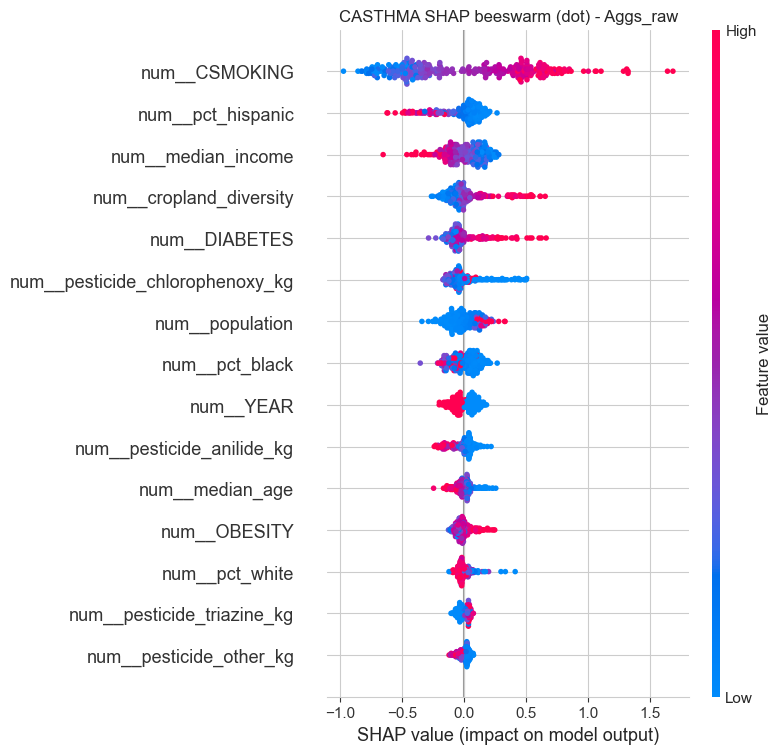

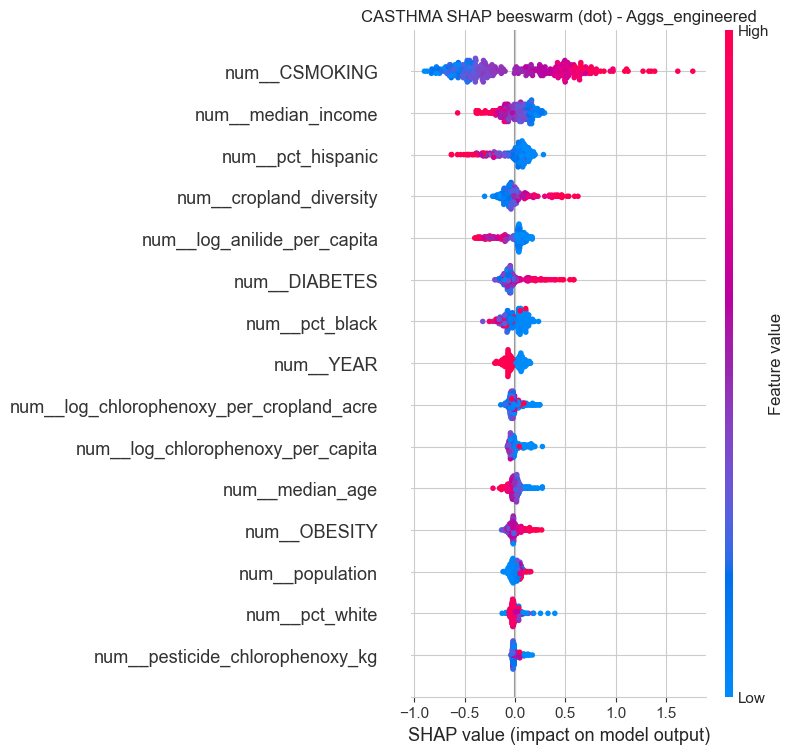

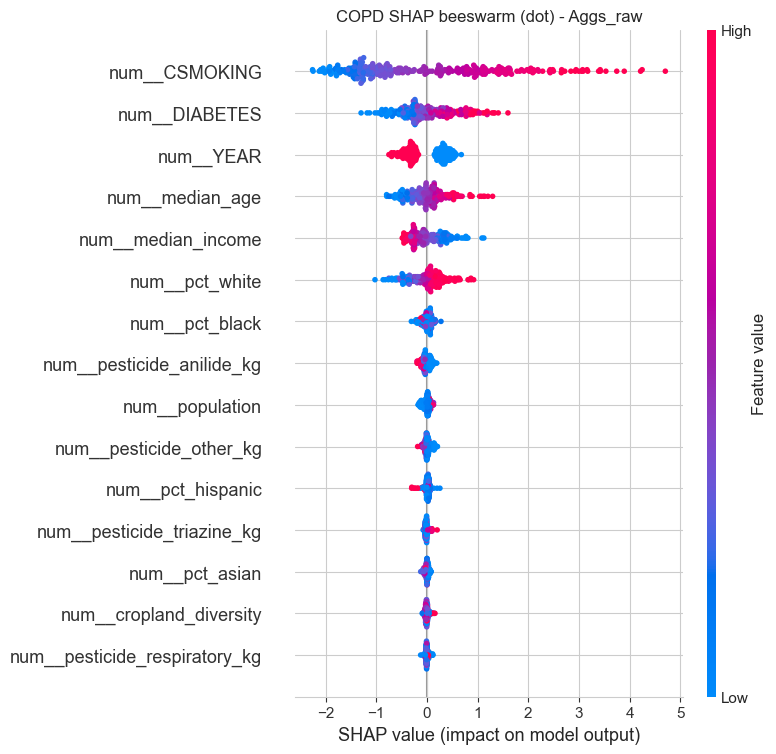

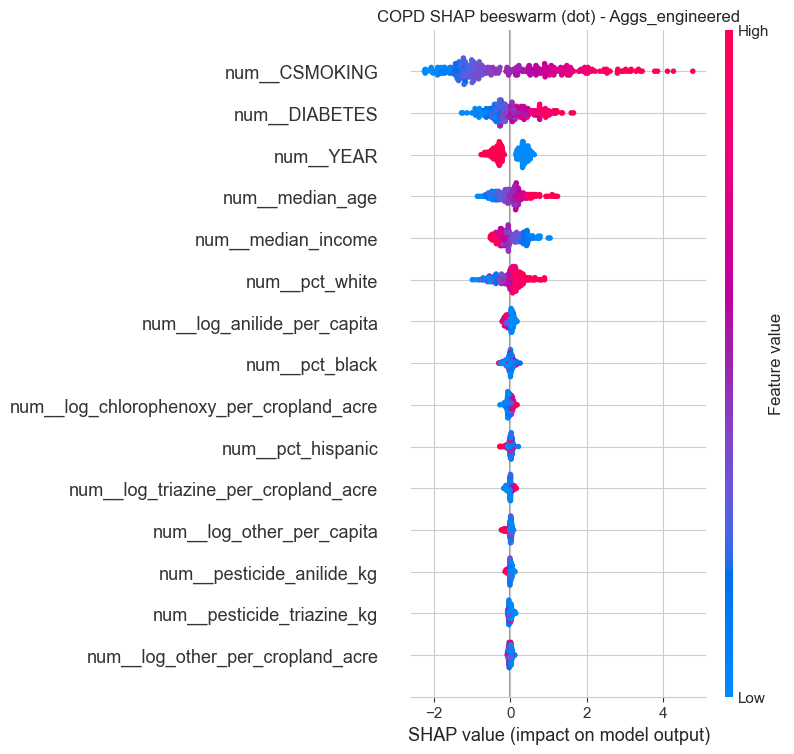

In [53]:
# --- SHAP (XGBoost): beeswarm/dot for both targets + raw vs engineered ---
try:
    import shap
    import numpy as np

    TOP_SHAP = 15
    SHAP_MAX_SAMPLES = 300

    # Plot SHAP for raw features plus the current engineered setting.
    # (If you change `PLOT_EXPOSURE_KEY` earlier, this will follow it.)
    exposures_to_plot = list(dict.fromkeys(["Aggs_raw", PLOT_EXPOSURE_KEY]))

    for t in TARGETS:
        for exposure_key in exposures_to_plot:
            bundle = fitted_store[(t, exposure_key)]
            xgb_search_t = bundle["xgb_search"]

            preprocess = xgb_search_t.best_estimator_.named_steps["preprocess"]
            xgb_model = xgb_search_t.best_estimator_.named_steps["model"]

            X_te = data[t]["X_by_exposure"][exposure_key][1]
            X_te_pre = preprocess.transform(X_te)

            if X_te_pre.shape[0] > SHAP_MAX_SAMPLES:
                rng = np.random.default_rng(RANDOM_STATE)
                idx = rng.choice(X_te_pre.shape[0], size=SHAP_MAX_SAMPLES, replace=False)
                X_te_pre = X_te_pre[idx]

            explainer = shap.TreeExplainer(xgb_model)
            shap_values = explainer.shap_values(X_te_pre)
            if isinstance(shap_values, list):
                shap_values = shap_values[0]

            feature_names = preprocess.get_feature_names_out()

            shap.summary_plot(
                shap_values,
                X_te_pre,
                feature_names=feature_names,
                max_display=TOP_SHAP,
                show=False,
            )
            plt.title(f"{t} SHAP beeswarm (dot) - {exposure_key}")
            plt.show()
except ImportError:
    print("Install shap: pip install shap")


---
## Interpretation

- **Best model**: Check the summary table (sorted by RMSE); typically XGBoost or ElasticNet/Lasso.
- **CV vs test**: `cv_rmse` (from grouped stratified CV) should be in the same ballpark as test RMSE; large gap suggests overfitting or distribution shift.
- **Uncertainty**: `rmse_ci_low` / `rmse_ci_high` are 95% bootstrap CIs for test RMSE; use them to compare models.
- **Features**: Ridge/Lasso/ElasticNet coefficients and XGBoost importance (and SHAP) show which predictors matter; compare across models for robustness.

## Full pipeline: summary export

Bootstrap CIs on test RMSE for every **target × exposure_set × model**; save CSVs under `modeling/results/<TARGET>/` (prediction exports use **Aggs_engineered**).


In [56]:
# --- Export: bootstrap RMSE CIs + save CSVs (uses `fitted_store` from models cell) ---

def bootstrap_ci(y_true, y_pred, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    rmse_boot = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        rmse_boot.append(np.sqrt(mean_squared_error(y_true.iloc[idx], y_pred[idx])))
    return np.percentile(rmse_boot, [2.5, 97.5])

combined_rows = []
for target in TARGETS:
    y_te = data[target]["y_test"]
    for ek in EXPOSURE_SET_KEYS:
        preds = fitted_store[(target, ek)]["preds"]
        for name, pred in preds.items():
            row = {"target": target, "exposure_set": ek, "model": name,
                "rmse": float(np.sqrt(mean_squared_error(y_te, pred))),
                "mae": float(mean_absolute_error(y_te, pred)), "r2": float(r2_score(y_te, pred))}
            lo, hi = bootstrap_ci(y_te, pred)
            row["rmse_ci_low"], row["rmse_ci_high"] = lo, hi
            combined_rows.append(row)
combined_summary = pd.DataFrame(combined_rows)
display(combined_summary.sort_values(["target", "exposure_set", "rmse"]))

for t in TARGETS:
    td = RESULTS_DIR / t
    td.mkdir(parents=True, exist_ok=True)
    combined_summary[combined_summary["target"] == t].to_csv(td / "model_summary_exposure_sets.csv", index=False)
    for exposure_key in ["Aggs_raw", "Aggs_engineered"]:
        b = fitted_store[(t, exposure_key)]
        y_te = data[t]["y_test"]
        td_df = data[t]["test_df"]
        for name, key in [("ridge", "pred_ridge"), ("lasso", "pred_lasso"), ("elasticnet", "pred_elastic"), ("xgboost", "pred_xgb")]:
            pred = b[key]
            pd.DataFrame({"FIPS": td_df["FIPS"], "YEAR": td_df["YEAR"], "actual": y_te, "prediction": pred}).to_csv(
                td / f"{name}_predictions_{exposure_key}.csv",
                index=False,
            )
        x_s = b["xgb_search"]
        fn = x_s.best_estimator_.named_steps["preprocess"].get_feature_names_out()
        im = x_s.best_estimator_.named_steps["model"].feature_importances_
        pd.DataFrame({"feature": fn, "importance": im}).sort_values("importance", ascending=False).head(25).to_csv(
            td / f"xgboost_top_importances_{exposure_key}.csv",
            index=False,
        )
        for nm, srch in [("ridge", b["ridge_search"]), ("lasso", b["lasso_search"]), ("elasticnet", b["elastic_search"])]:
            top_coefficients(srch).to_csv(td / f"{nm}_top_coefficients_{exposure_key}.csv", index=False)
    print(f"Saved {t}")


,target,exposure_set,model,rmse,mae,r2,rmse_ci_low,rmse_ci_high
13,CASTHMA,Aggs_engineered,XGBoost (tuned),0.452622,0.346478,0.792281,0.427956,0.477298
11,CASTHMA,Aggs_engineered,Lasso (tuned),0.601335,0.472490,0.633361,0.573922,0.626846
12,CASTHMA,Aggs_engineered,ElasticNet (tuned),0.602008,0.473536,0.632540,0.574765,0.627262
10,CASTHMA,Aggs_engineered,Ridge (tuned),0.602548,0.474111,0.631881,0.575410,0.627711
8,CASTHMA,Aggs_engineered,"Multiple LR (Ridge, numeric)",0.602875,0.474430,0.631481,0.575803,0.628017
...,...,...,...,...,...,...,...,...
67,COPD,Full_pesticides_raw,Lasso (tuned),0.875681,0.649689,0.855933,0.822144,0.933520
66,COPD,Full_pesticides_raw,Ridge (tuned),0.985333,0.681141,0.817594,0.890372,1.099477
63,COPD,Full_pesticides_raw,Simple LR (1 feat),2.297147,1.844011,0.008597,2.199796,2.386740
64,COPD,Full_pesticides_raw,"Multiple LR (Ridge, numeric)",4.287777,0.921852,-2.454117,1.726525,6.231317


Saved CASTHMA
Saved COPD


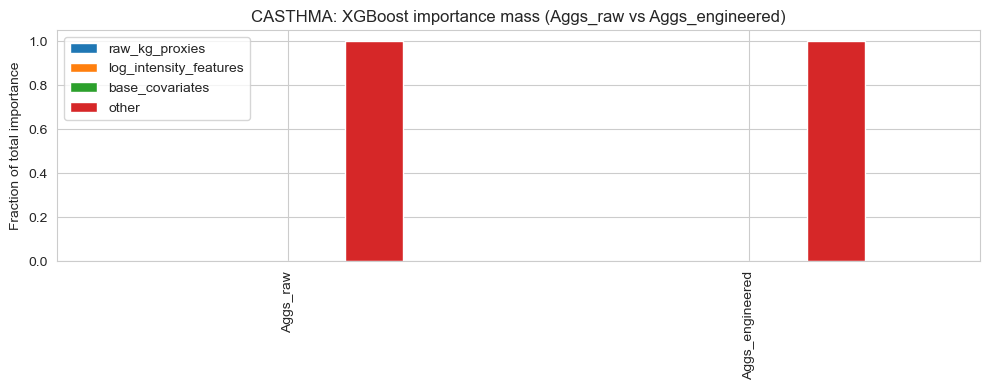

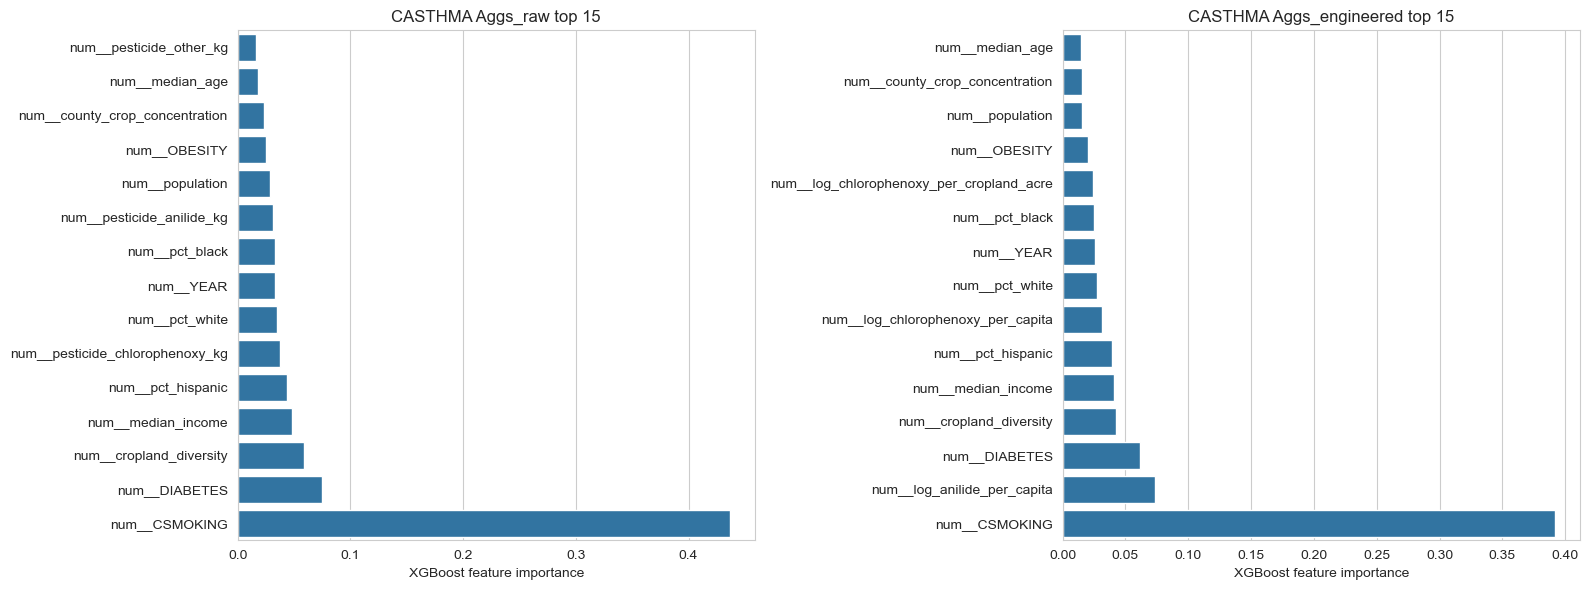

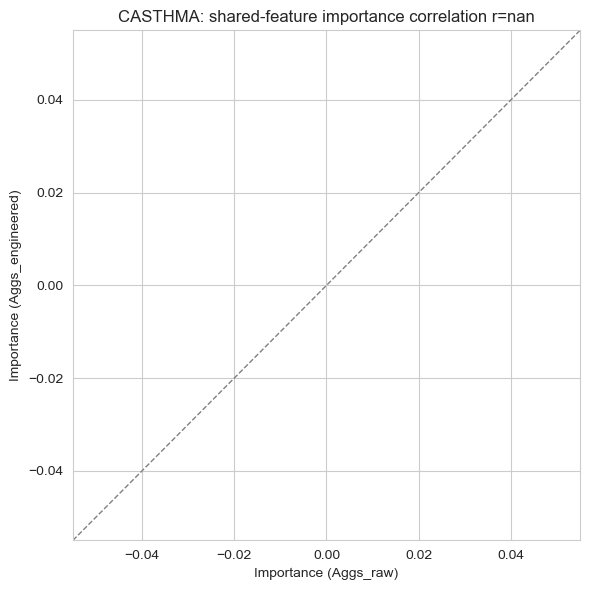

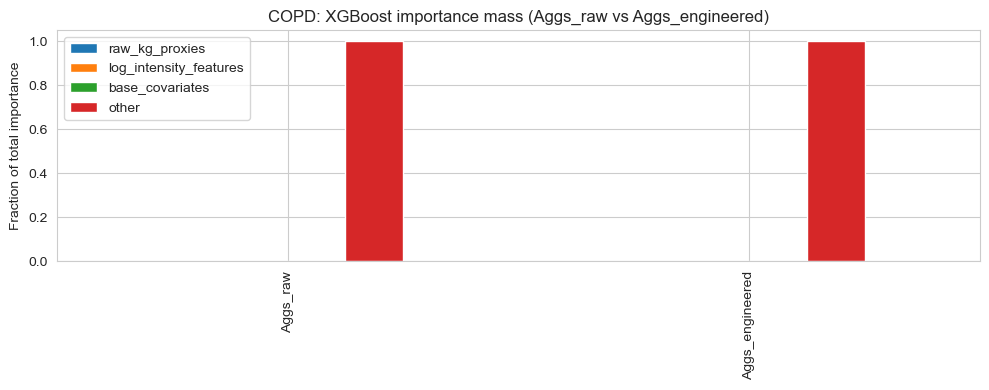

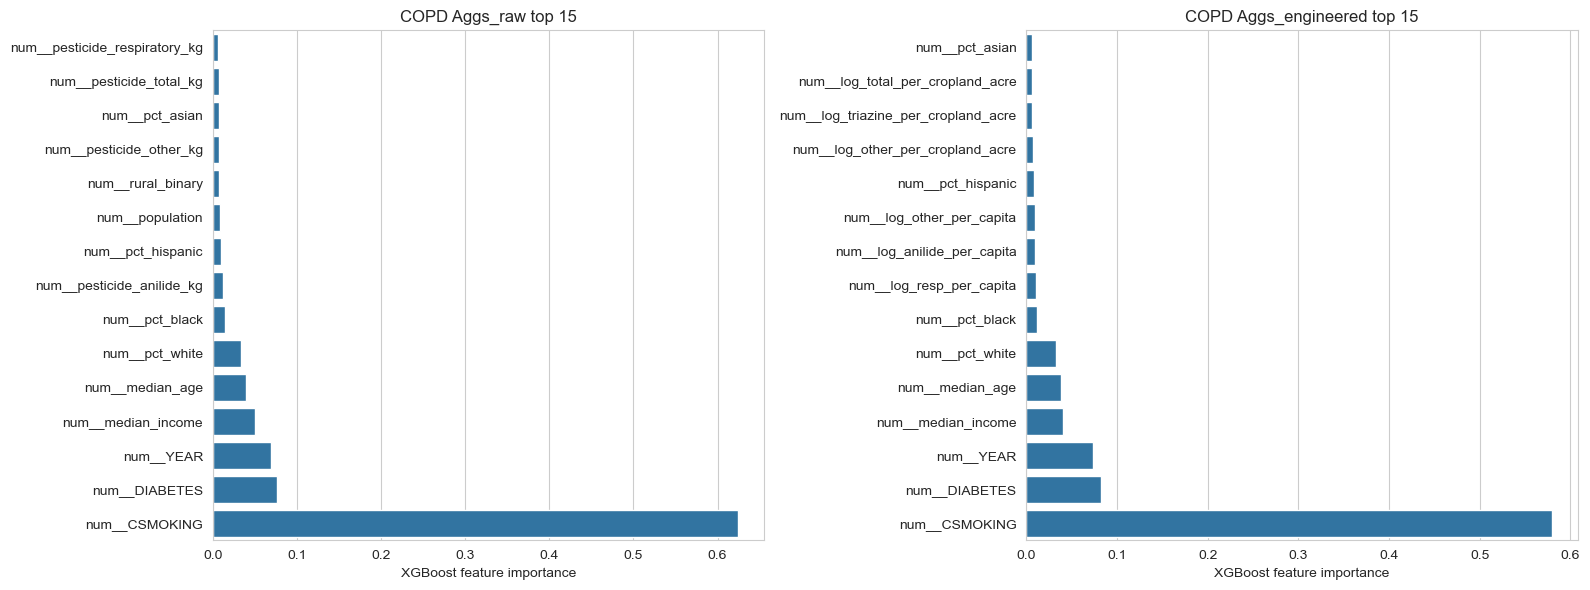

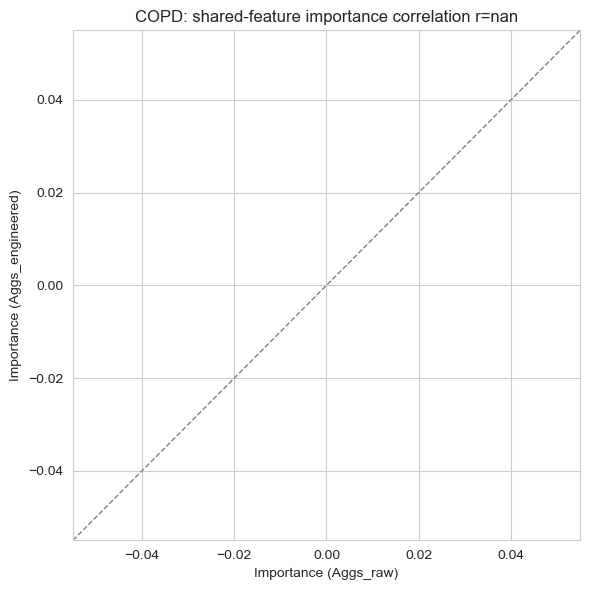

In [55]:
# --- Visualization: XGBoost feature-importance comparison (raw vs engineered) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

RAW_EXPOSURE_KEY = "Aggs_raw"
ENG_EXPOSURE_KEY = "Aggs_engineered"
TOP_K = 15

DO_SHAP_COMPARISON = False  # set True if you want SHAP summary plots (slower)
MAX_SHAP_SAMPLES = 300
TOP_SHAP_DISPLAY = 15


def xgb_importance_df(target: str, exposure_key: str) -> pd.DataFrame:
    bundle = fitted_store[(target, exposure_key)]
    xgb_search = bundle["xgb_search"]
    preprocess = xgb_search.best_estimator_.named_steps["preprocess"]
    model = xgb_search.best_estimator_.named_steps["model"]

    feature_names = preprocess.get_feature_names_out()
    importances = model.feature_importances_

    return pd.DataFrame({"feature": feature_names, "importance": importances})


def group_importance_mass(df: pd.DataFrame) -> pd.Series:
    total = float(df["importance"].sum())
    if total <= 0:
        return pd.Series({
            "raw_kg_proxies": np.nan,
            "log_intensity_features": np.nan,
            "base_covariates": np.nan,
            "other": np.nan,
        })

    raw_kg = set(AGGREGATE_KG_PROXIES)
    log_int = set(AGGREGATE_LOG_INTENSITY)
    base_cov = set(BASE_COLS)

    def sum_for(feature_set):
        return float(df.loc[df["feature"].isin(feature_set), "importance"].sum())

    raw_mass = sum_for(raw_kg) / total
    log_mass = sum_for(log_int) / total
    base_mass = sum_for(base_cov) / total
    other_mass = max(0.0, 1.0 - (raw_mass + log_mass + base_mass))

    return pd.Series({
        "raw_kg_proxies": raw_mass,
        "log_intensity_features": log_mass,
        "base_covariates": base_mass,
        "other": other_mass,
    })


def plot_top_importances(df: pd.DataFrame, title: str, ax: plt.Axes, top_k: int = TOP_K):
    d = df.sort_values("importance", ascending=False).head(top_k).copy()
    d = d.iloc[::-1]  # so the largest is at the top in a horizontal bar chart
    sns.barplot(ax=ax, x="importance", y="feature", data=d, orient="h")
    ax.set_title(title)
    ax.set_xlabel("XGBoost feature importance")
    ax.set_ylabel("")


for t in TARGETS:
    df_raw = xgb_importance_df(t, RAW_EXPOSURE_KEY)
    df_eng = xgb_importance_df(t, ENG_EXPOSURE_KEY)

    # 1) Importance mass by feature group (normalized to sum=1)
    mass = pd.concat([
        group_importance_mass(df_raw).rename(RAW_EXPOSURE_KEY),
        group_importance_mass(df_eng).rename(ENG_EXPOSURE_KEY),
    ], axis=1).T

    fig, ax = plt.subplots(figsize=(10, 4))
    mass.plot(kind="bar", ax=ax)
    ax.set_title(f"{t}: XGBoost importance mass (Aggs_raw vs Aggs_engineered)")
    ax.set_ylabel("Fraction of total importance")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.show()

    # 2) Top-K feature importance comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    plot_top_importances(df_raw, f"{t} {RAW_EXPOSURE_KEY} top {TOP_K}", axes[0])
    plot_top_importances(df_eng, f"{t} {ENG_EXPOSURE_KEY} top {TOP_K}", axes[1])
    plt.tight_layout()
    plt.show()

    # 3) Correlation on shared features (raw kg proxies + base covariates)
    shared = set(AGGREGATE_KG_PROXIES).union(set(BASE_COLS))

    raw_shared = df_raw[df_raw["feature"].isin(shared)].set_index("feature")["importance"]
    eng_shared = df_eng[df_eng["feature"].isin(shared)].set_index("feature")["importance"]

    common_features = raw_shared.index.intersection(eng_shared.index)
    plot_df = pd.DataFrame({
        "raw": raw_shared.loc[common_features].values,
        "engineered": eng_shared.loc[common_features].values,
        "feature": list(common_features),
    })

    corr = float(pd.Series(plot_df["raw"]).corr(pd.Series(plot_df["engineered"])))

    fig, ax = plt.subplots(figsize=(6, 6))
    sns.scatterplot(x="raw", y="engineered", data=plot_df, ax=ax, s=35)
    ax.axline((0, 0), slope=1, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{t}: shared-feature importance correlation r={corr:.2f}")
    ax.set_xlabel(f"Importance ({RAW_EXPOSURE_KEY})")
    ax.set_ylabel(f"Importance ({ENG_EXPOSURE_KEY})")

    # Annotate a few of the most important shared raw features
    ann = plot_df.sort_values("raw", ascending=False).head(6)
    for _, row in ann.iterrows():
        ax.annotate(row["feature"], (row["raw"], row["engineered"]), fontsize=8, alpha=0.8)

    plt.tight_layout()
    plt.show()

    # Optional: SHAP summary plots
    if DO_SHAP_COMPARISON:
        try:
            import shap
        except ImportError:
            print("SHAP not installed. Install with: pip install shap")
            break

        for exposure_key in [RAW_EXPOSURE_KEY, ENG_EXPOSURE_KEY]:
            xgb_search = fitted_store[(t, exposure_key)]["xgb_search"]
            preprocess = xgb_search.best_estimator_.named_steps["preprocess"]
            xgb_model = xgb_search.best_estimator_.named_steps["model"]

            X_te = data[t]["X_by_exposure"][exposure_key][1]
            X_te_pre = preprocess.transform(X_te)

            if X_te_pre.shape[0] > MAX_SHAP_SAMPLES:
                rng = np.random.default_rng(RANDOM_STATE)
                idx = rng.choice(X_te_pre.shape[0], size=MAX_SHAP_SAMPLES, replace=False)
                X_te_pre = X_te_pre[idx]

            feature_names = preprocess.get_feature_names_out()
            explainer = shap.TreeExplainer(xgb_model)
            shap_values = explainer.shap_values(X_te_pre)

            # Guard: some SHAP APIs return a list (e.g., multi-output)
            if isinstance(shap_values, list):
                shap_values = shap_values[0]

            shap.summary_plot(
                shap_values,
                X_te_pre,
                feature_names=feature_names,
                max_display=TOP_SHAP_DISPLAY,
                show=False,
            )
            plt.title(f"{t} SHAP summary ({exposure_key})")
            plt.tight_layout()
            plt.show()


**Optional:** Re-run the **Export** code cell to refresh `modeling/results/<TARGET>/`.


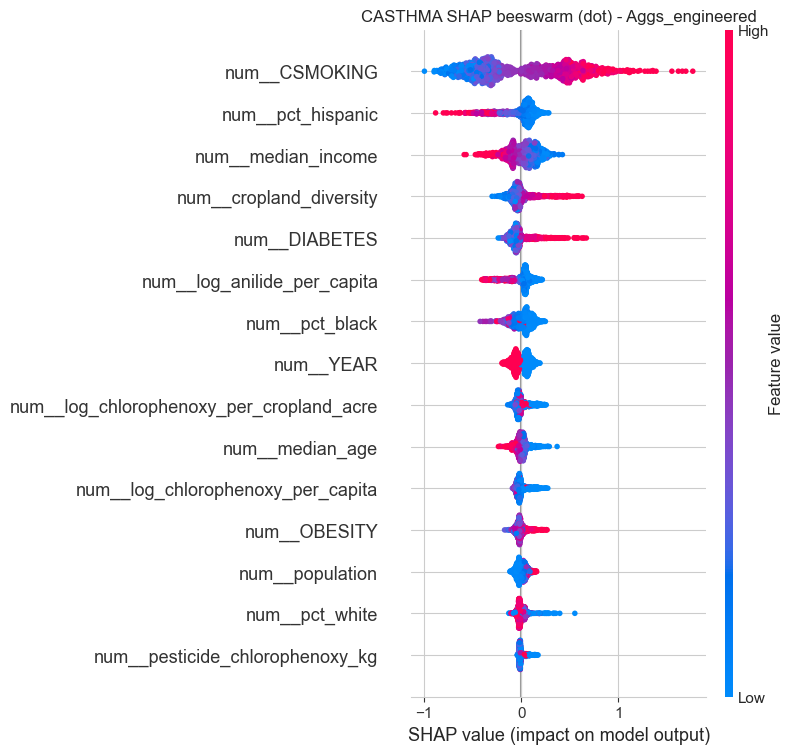

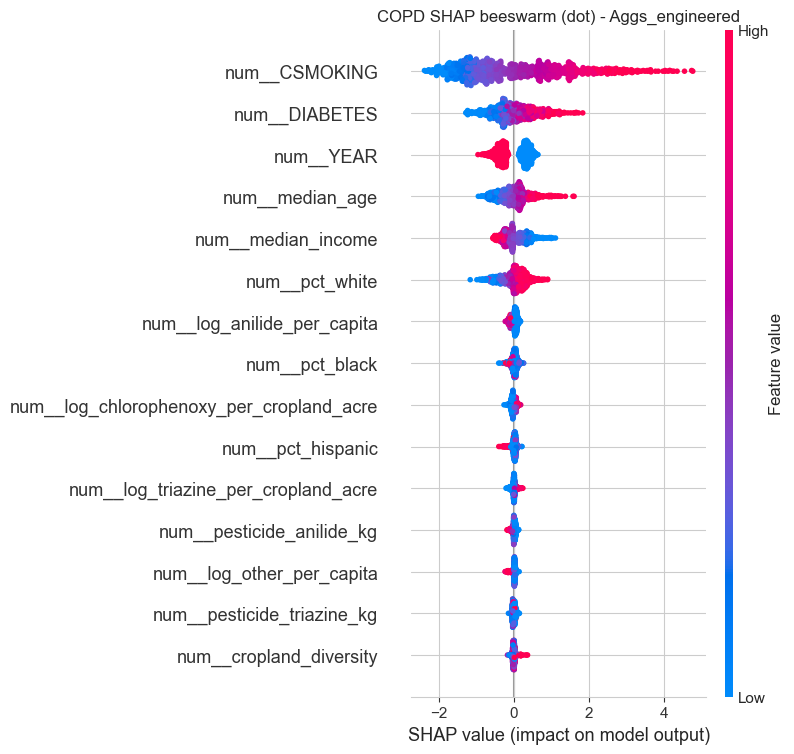

In [49]:
# Moved up into the `## SHAP (XGBoost)` section (cell 15) for readability.
# Run cell 15 instead.
